## Laboratorium 1

### Autor: Michał Kowalczyk

### Importy

In [20]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Generowanie syntetycznych danych

Z użyciem biblioteki numpy wygenerowany zostaje wektor losowych danych od 0 do 10 oraz szum z rozkładu Gaussa który jest używany do obliczenia wartości wektora docelowego y.

In [12]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10

epsilon = np.random.normal(0, 1, 100)

y = 2 * X.flatten() + 5 + epsilon

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 1)
y shape: (100,)


### 2. Przygotowanie danych

In [13]:
X = np.hstack((np.ones((100, 1)), X))

X.shape

(100, 2)

### 3. Inicjalizacja parametrów

Zainicjalizowany zostaje wektor parametrów.

In [14]:
w = np.zeros(2)

### 4. Implementacja algorytmu spadku gradientu

Funkcja implementuje gradient descent dla regresji liniowej.

X – macierz cech (z biasem w pierwszej kolumnie)

y – wektor celów

w – wektor wag początkowych

lr – learning rate

epochs – liczba iteracji treningowych

W każdej iteracji pętli obliczona zostaje aktualna wartość funkcji straty, która jest wykorzystywana do obliczenia gradientu. Mając już wartość gradientu obliczana jest kolejna wartość wektora wag. Dodatkowo dla każdej epoki wartość funkcji straty zapisywana jest do listy, dzięki czemu możliwa jest późniejsza analiza przebiegu treningu.

In [40]:
def gradient_descent(X, y, w, lr=0.001, epochs=1000):
    n = len(y)

    loss_history = []

    for epoch in range(epochs):

        y_hat = X @ w

        loss = np.mean((y_hat - y)**2)

        loss_history.append(loss)

        grad = (1/n) * X.T @ (y_hat - y)

        w = w - lr * grad

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return w, loss_history

### 5. Uruchamianie pętli treningowej

In [19]:
w, loss_history = gradient_descent(X, y, w)

print("Learned weights:", w)
print("Final loss:", loss_history[-1])

Epoch 0, Loss: 2.9644
Epoch 100, Loss: 2.8480
Epoch 200, Loss: 2.7378
Epoch 300, Loss: 2.6336
Epoch 400, Loss: 2.5350
Epoch 500, Loss: 2.4417
Epoch 600, Loss: 2.3535
Epoch 700, Loss: 2.2700
Epoch 800, Loss: 2.1910
Epoch 900, Loss: 2.1163
Learned weights: [3.125941   2.27512227]
Final loss: 2.0463377576903223


### 6. Sprawdzenie wyników

Poniżej została zaimplementowana funkcja do wizualizacji otrzymanej funkcji liniowej na tle punktów danych treningowych.

In [ ]:
def plot_regression(X, y, w):
    x_vals = X[:, 1]

    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_pred = w[0] + w[1] * x_line

    y_true = 5 + 2 * x_line

    plt.figure()
    plt.scatter(x_vals, y, label="Data")
    plt.plot(x_line, y_pred, label="Fitted model")
    plt.plot(x_line, y_true, linestyle="--", label="Ground truth")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Linear Regression Fit")
    plt.legend()
    plt.show()

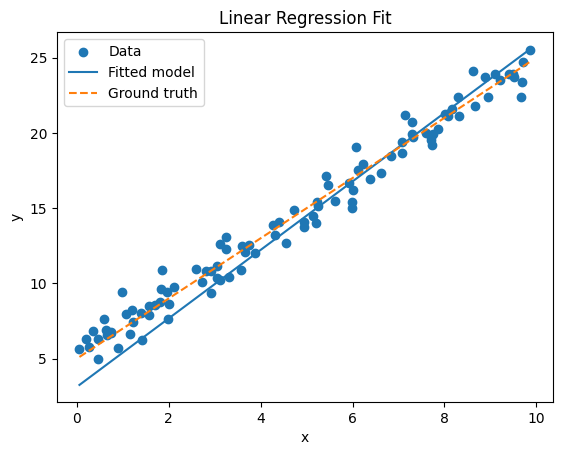

In [33]:
plot_regression(X, y, w)

### 7. Eksperymenty ze współczynnikiem uczenia

W tej sekcji przeprowadzane są eksperymenty dla różynch wartości współczynnika uczenia.

In [ ]:
def plot_loss(loss_history):
    plt.figure()
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Training Loss")
    plt.show()

Training with learning rate: 0.1
Epoch 0, Loss: 241.6928
Final weights for lr=0.1: [-1.10742526e+33 -7.20518874e+33]
Final loss for lr=0.1: 360117951090699794824957421418486367272188965014545876315862013575168.0000


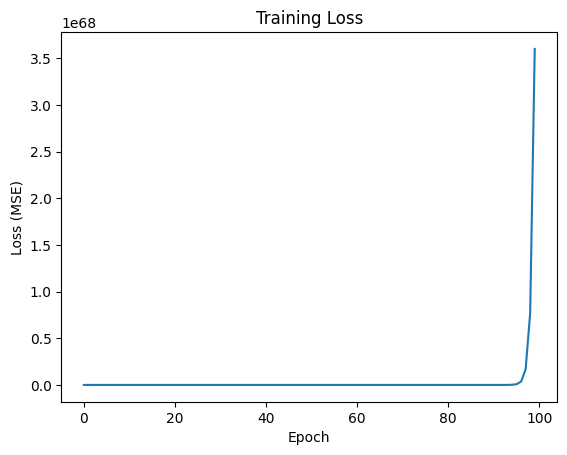

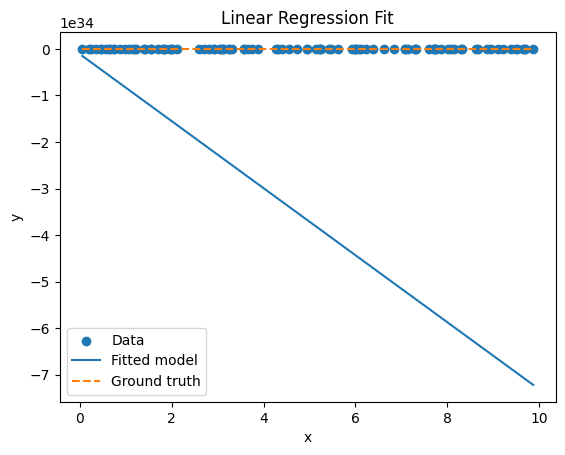

Training with learning rate: 0.01
Epoch 0, Loss: 241.6928
Final weights for lr=0.01: [1.57805591 2.51302958]
Final loss for lr=0.01: 4.5828


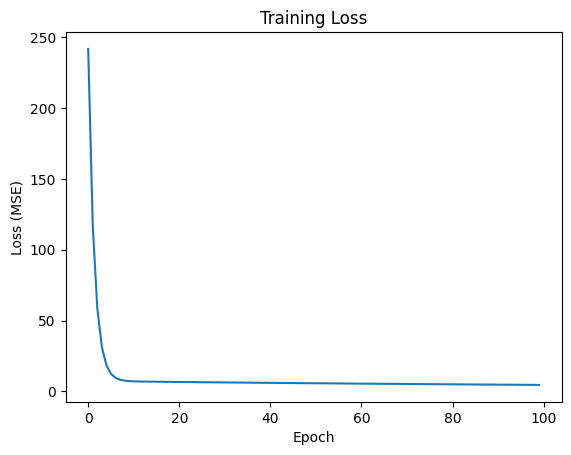

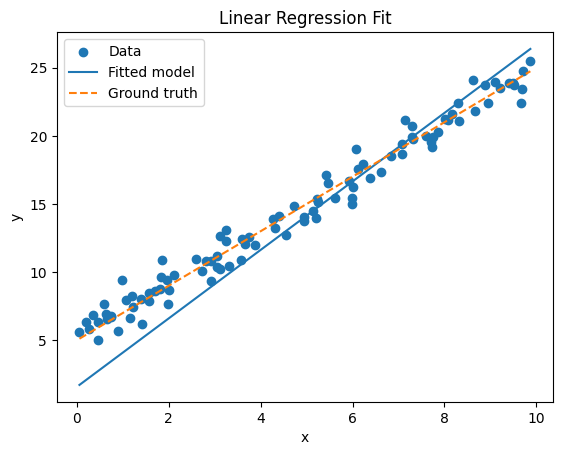

Training with learning rate: 0.001
Epoch 0, Loss: 241.6928
Final weights for lr=0.001: [0.52840568 2.56316355]
Final loss for lr=0.001: 7.4083


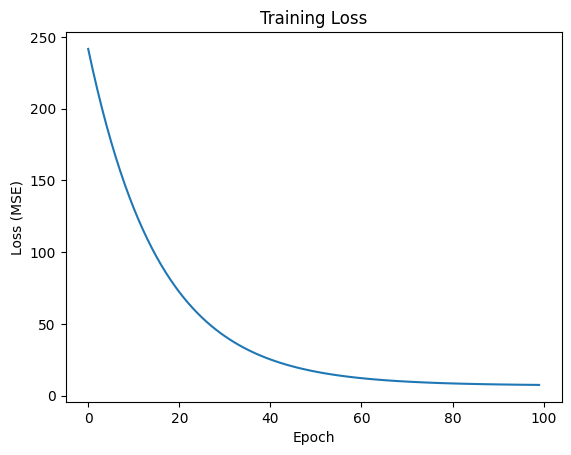

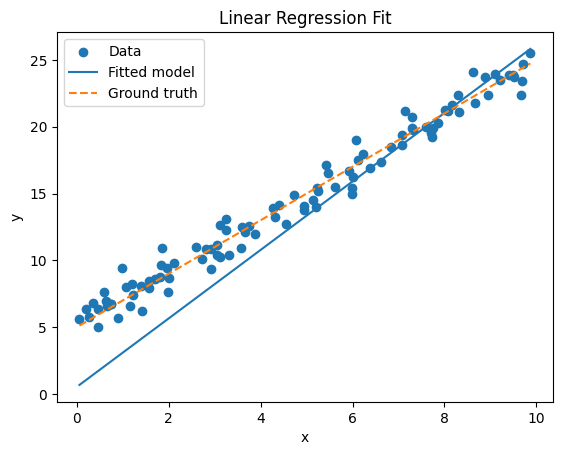

Training with learning rate: 0.0001
Epoch 0, Loss: 241.6928
Final weights for lr=0.0001: [0.12552434 0.72813047]
Final loss for lr=0.0001: 132.5620


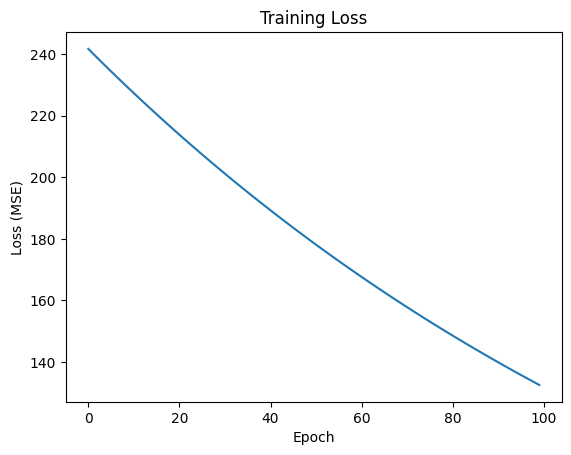

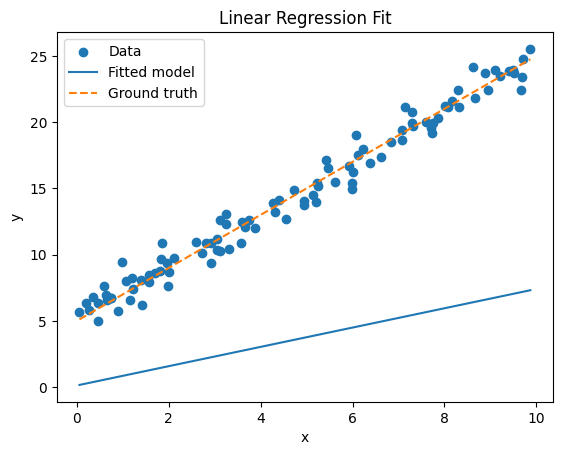

Training with learning rate: 1e-05
Epoch 0, Loss: 241.6928
Final weights for lr=1e-05: [0.01420005 0.08352188]
Final loss for lr=1e-05: 227.4778


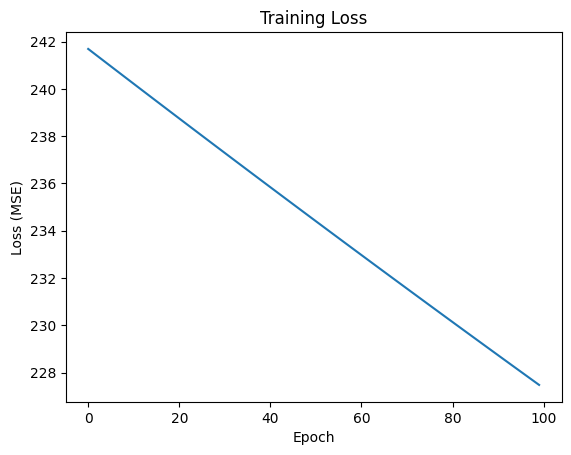

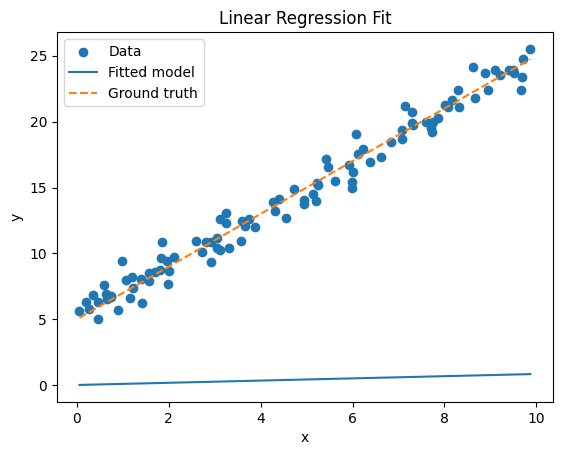

Training with learning rate: 1e-06
Epoch 0, Loss: 241.6928
Final weights for lr=1e-06: [0.00143821 0.00847053]
Final loss for lr=1e-06: 240.2311


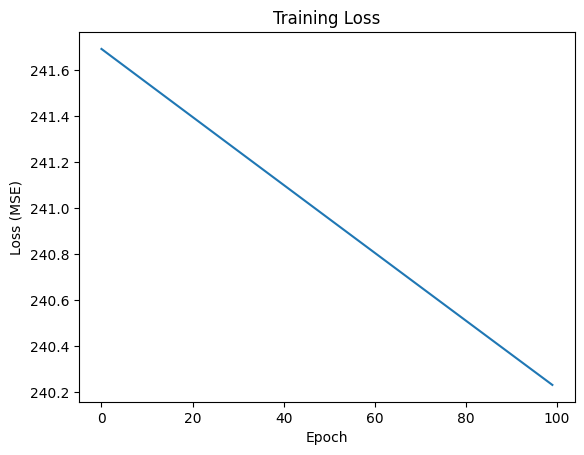

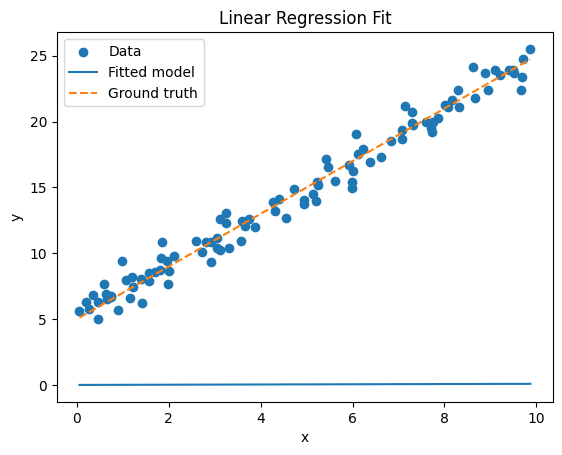

In [46]:
learning_rates = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

for lr in learning_rates:
    print(f'Training with learning rate: {lr}')
    w, loss_history = gradient_descent(X, y, np.zeros(2), lr=lr, epochs=100)
    print(f'Final weights for lr={lr}: {w}')
    print(f'Final loss for lr={lr}: {loss_history[-1]:.4f}')
    plot_loss(loss_history)
    plot_regression(X, y, w)

### 8. Eksperymentowanie z czasem trwania treningu

Training with epochs: 100
Epoch 0, Loss: 241.6928
Final weights for lr=1e-06: [0.52840568 2.56316355]
Final loss for lr=1e-06: 7.4083
Epochs:  100 | Learned w: [0.52840568 2.56316355] | Distance to true w: 4.5069


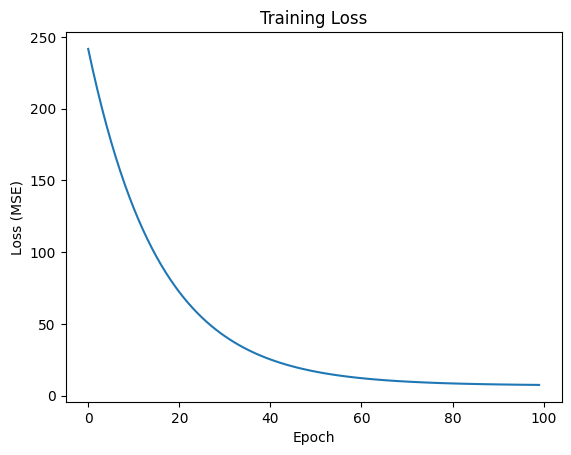

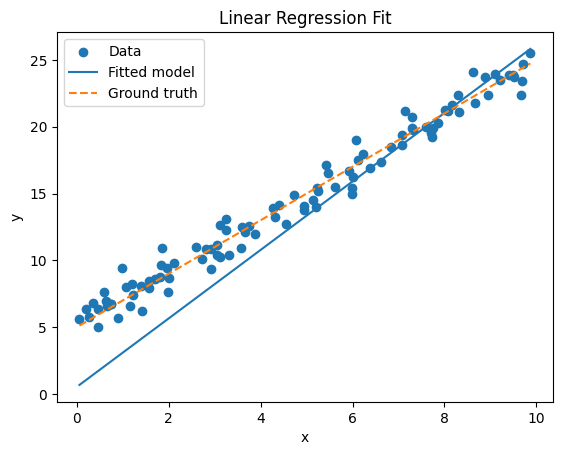

Training with epochs: 500
Epoch 0, Loss: 241.6928
Epoch 100, Loss: 7.3795
Epoch 200, Loss: 6.6644
Epoch 300, Loss: 6.3477
Epoch 400, Loss: 6.0487
Final weights for lr=1e-06: [1.03553437 2.59641392]
Final loss for lr=1e-06: 5.7686
Epochs:  500 | Learned w: [1.03553437 2.59641392] | Distance to true w: 4.0091


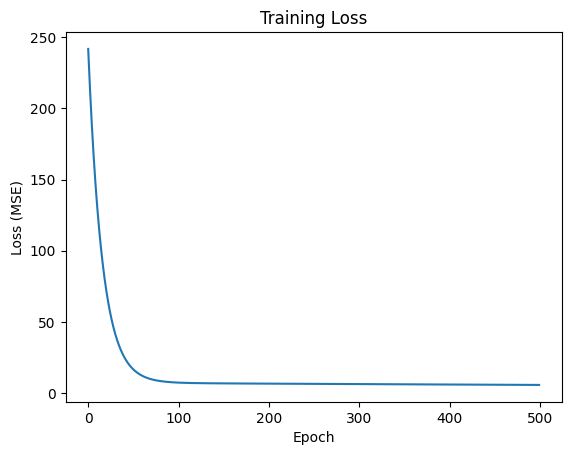

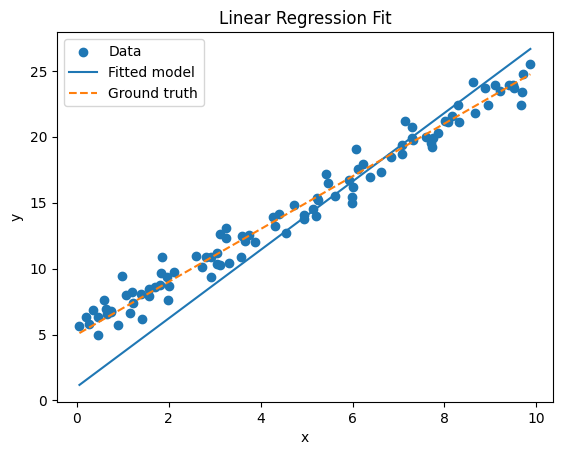

Training with epochs: 1000
Epoch 0, Loss: 241.6928
Epoch 100, Loss: 7.3795
Epoch 200, Loss: 6.6644
Epoch 300, Loss: 6.3477
Epoch 400, Loss: 6.0487
Epoch 500, Loss: 5.7658
Epoch 600, Loss: 5.4982
Epoch 700, Loss: 5.2450
Epoch 800, Loss: 5.0055
Epoch 900, Loss: 4.7789
Final weights for lr=1e-06: [1.57679424 2.5132235 ]
Final loss for lr=1e-06: 4.5666
Epochs: 1000 | Learned w: [1.57679424 2.5132235 ] | Distance to true w: 3.4615


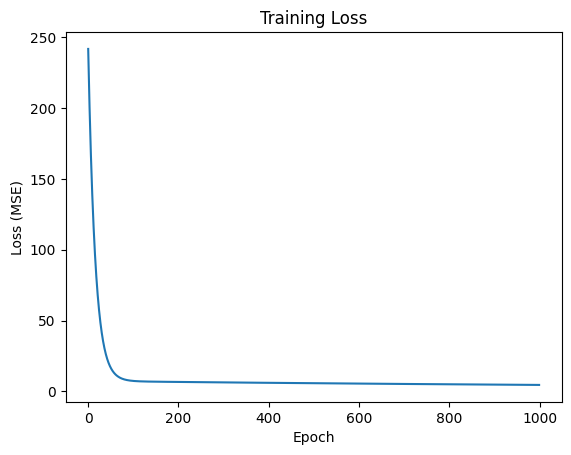

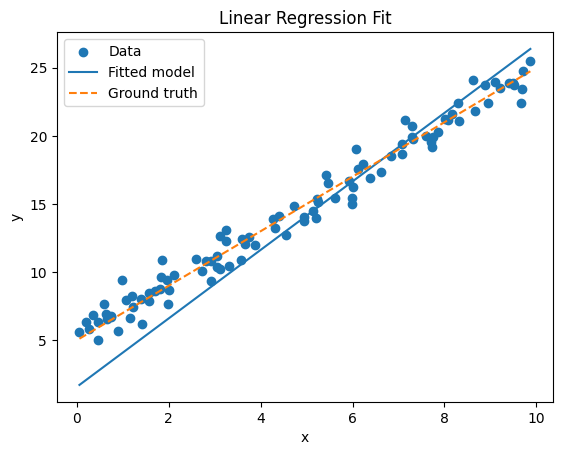

Training with epochs: 5000
Epoch 0, Loss: 241.6928
Epoch 100, Loss: 7.3795
Epoch 200, Loss: 6.6644
Epoch 300, Loss: 6.3477
Epoch 400, Loss: 6.0487
Epoch 500, Loss: 5.7658
Epoch 600, Loss: 5.4982
Epoch 700, Loss: 5.2450
Epoch 800, Loss: 5.0055
Epoch 900, Loss: 4.7789
Epoch 1000, Loss: 4.5645
Epoch 1100, Loss: 4.3617
Epoch 1200, Loss: 4.1699
Epoch 1300, Loss: 3.9884
Epoch 1400, Loss: 3.8167
Epoch 1500, Loss: 3.6542
Epoch 1600, Loss: 3.5006
Epoch 1700, Loss: 3.3552
Epoch 1800, Loss: 3.2176
Epoch 1900, Loss: 3.0875
Epoch 2000, Loss: 2.9644
Epoch 2100, Loss: 2.8480
Epoch 2200, Loss: 2.7378
Epoch 2300, Loss: 2.6336
Epoch 2400, Loss: 2.5350
Epoch 2500, Loss: 2.4417
Epoch 2600, Loss: 2.3535
Epoch 2700, Loss: 2.2700
Epoch 2800, Loss: 2.1910
Epoch 2900, Loss: 2.1163
Epoch 3000, Loss: 2.0457
Epoch 3100, Loss: 1.9788
Epoch 3200, Loss: 1.9155
Epoch 3300, Loss: 1.8557
Epoch 3400, Loss: 1.7991
Epoch 3500, Loss: 1.7455
Epoch 3600, Loss: 1.6948
Epoch 3700, Loss: 1.6469
Epoch 3800, Loss: 1.6016
Epoch 39

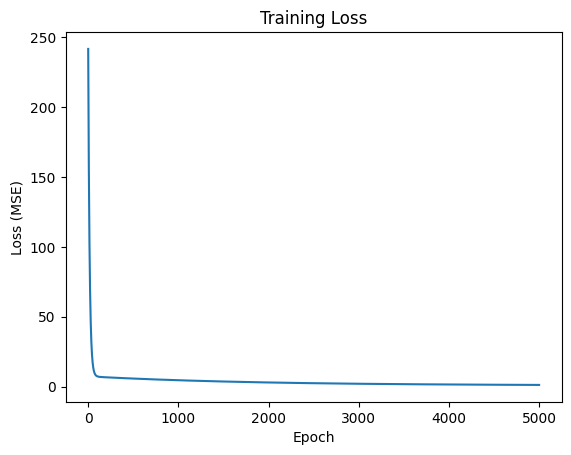

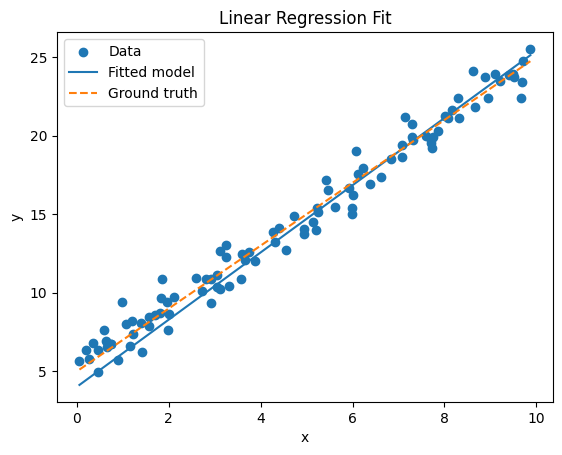

Training with epochs: 10000
Epoch 0, Loss: 241.6928
Epoch 100, Loss: 7.3795
Epoch 200, Loss: 6.6644
Epoch 300, Loss: 6.3477
Epoch 400, Loss: 6.0487
Epoch 500, Loss: 5.7658
Epoch 600, Loss: 5.4982
Epoch 700, Loss: 5.2450
Epoch 800, Loss: 5.0055
Epoch 900, Loss: 4.7789
Epoch 1000, Loss: 4.5645
Epoch 1100, Loss: 4.3617
Epoch 1200, Loss: 4.1699
Epoch 1300, Loss: 3.9884
Epoch 1400, Loss: 3.8167
Epoch 1500, Loss: 3.6542
Epoch 1600, Loss: 3.5006
Epoch 1700, Loss: 3.3552
Epoch 1800, Loss: 3.2176
Epoch 1900, Loss: 3.0875
Epoch 2000, Loss: 2.9644
Epoch 2100, Loss: 2.8480
Epoch 2200, Loss: 2.7378
Epoch 2300, Loss: 2.6336
Epoch 2400, Loss: 2.5350
Epoch 2500, Loss: 2.4417
Epoch 2600, Loss: 2.3535
Epoch 2700, Loss: 2.2700
Epoch 2800, Loss: 2.1910
Epoch 2900, Loss: 2.1163
Epoch 3000, Loss: 2.0457
Epoch 3100, Loss: 1.9788
Epoch 3200, Loss: 1.9155
Epoch 3300, Loss: 1.8557
Epoch 3400, Loss: 1.7991
Epoch 3500, Loss: 1.7455
Epoch 3600, Loss: 1.6948
Epoch 3700, Loss: 1.6469
Epoch 3800, Loss: 1.6016
Epoch 3

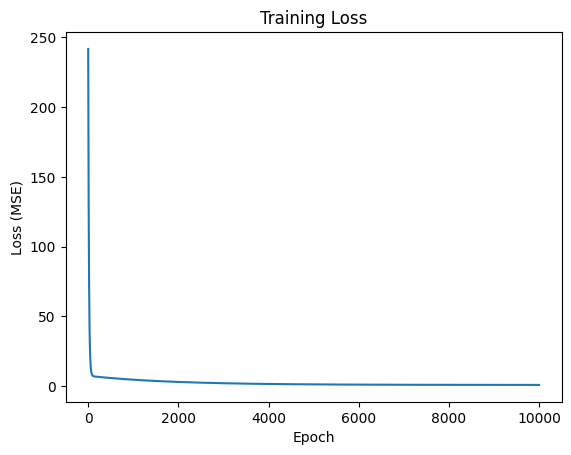

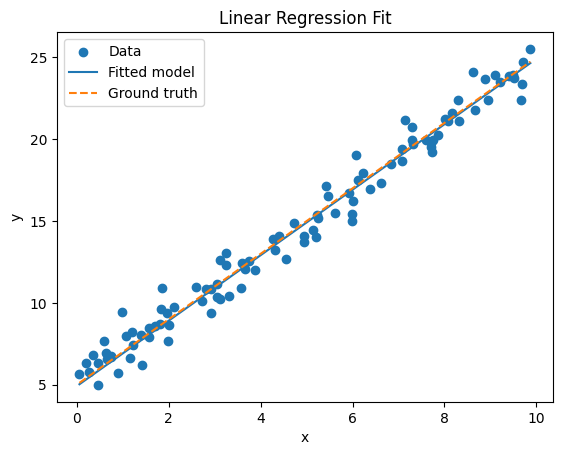

In [47]:
epochs_list = [100, 500, 1000, 5000, 10000]

true_w = np.array([5, 2])

for epochs in epochs_list:
    print(f'Training with epochs: {epochs}')
    w, loss_history = gradient_descent(X, y, np.zeros(2), lr=0.001, epochs=epochs)
    print(f'Final weights for lr={lr}: {w}')
    print(f'Final loss for lr={lr}: {loss_history[-1]:.4f}')
    dist = np.linalg.norm(w - true_w)
    print(f"Epochs: {epochs:4d} | Learned w: {w} | Distance to true w: {dist:.4f}")
    plot_loss(loss_history)
    plot_regression(X, y, w)

### 9. Wizualizacja straty

Ta sekcja zawiera wizualizacje funkcji straty, która jest optymalizowana w algorytmie spadku gradientu.

Epoch 0, Loss: 241.6928
Epoch 100, Loss: 7.3795
Epoch 200, Loss: 6.6644
Epoch 300, Loss: 6.3477
Epoch 400, Loss: 6.0487
Epoch 500, Loss: 5.7658
Epoch 600, Loss: 5.4982
Epoch 700, Loss: 5.2450
Epoch 800, Loss: 5.0055
Epoch 900, Loss: 4.7789


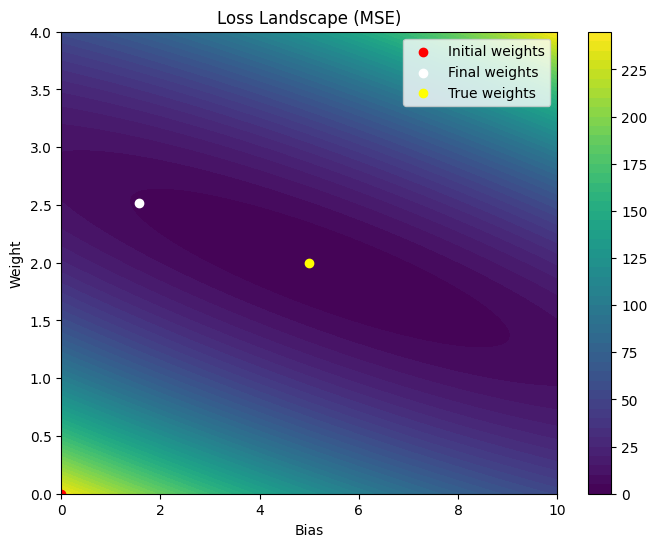

Epoch 0, Loss: 4.5645
Epoch 100, Loss: 4.3617
Epoch 200, Loss: 4.1699
Epoch 300, Loss: 3.9884
Epoch 400, Loss: 3.8167
Epoch 500, Loss: 3.6542
Epoch 600, Loss: 3.5006
Epoch 700, Loss: 3.3552
Epoch 800, Loss: 3.2176
Epoch 900, Loss: 3.0875
Epoch 1000, Loss: 2.9644
Epoch 1100, Loss: 2.8480
Epoch 1200, Loss: 2.7378
Epoch 1300, Loss: 2.6336
Epoch 1400, Loss: 2.5350
Epoch 1500, Loss: 2.4417
Epoch 1600, Loss: 2.3535
Epoch 1700, Loss: 2.2700
Epoch 1800, Loss: 2.1910
Epoch 1900, Loss: 2.1163
Epoch 2000, Loss: 2.0457
Epoch 2100, Loss: 1.9788
Epoch 2200, Loss: 1.9155
Epoch 2300, Loss: 1.8557
Epoch 2400, Loss: 1.7991
Epoch 2500, Loss: 1.7455
Epoch 2600, Loss: 1.6948
Epoch 2700, Loss: 1.6469
Epoch 2800, Loss: 1.6016
Epoch 2900, Loss: 1.5587
Epoch 3000, Loss: 1.5181
Epoch 3100, Loss: 1.4797
Epoch 3200, Loss: 1.4434
Epoch 3300, Loss: 1.4090
Epoch 3400, Loss: 1.3765
Epoch 3500, Loss: 1.3457
Epoch 3600, Loss: 1.3166
Epoch 3700, Loss: 1.2891
Epoch 3800, Loss: 1.2631
Epoch 3900, Loss: 1.2384
Epoch 4000, 

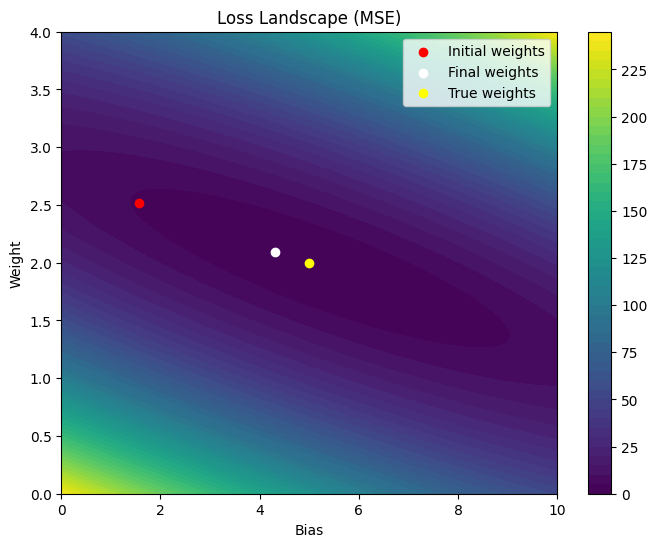

In [50]:
b_vals = np.linspace(0, 10, 100) # biasy
w_vals = np.linspace(0, 4, 100) # wagi

B, W = np.meshgrid(b_vals, w_vals)
Loss = np.zeros_like(B)

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        w_try = np.array([B[i,j], W[i,j]])
        y_hat = X @ w_try
        Loss[i,j] = np.mean((y - y_hat)**2)

w_final, loss_history = gradient_descent(X, y, np.zeros(2), lr=0.001, epochs=1000)

w_true = np.array([5, 2])
w_init = np.array([0,0])

plt.figure(figsize=(8,6))
contour = plt.contourf(B, W, Loss, levels=50, cmap="viridis")
plt.colorbar(contour)
plt.xlabel("Bias")
plt.ylabel("Weight")
plt.title("Loss Landscape (MSE)")

plt.scatter(w_init[0], w_init[1], color='red', label="Initial weights")
plt.scatter(w_final[0], w_final[1], color='white', label="Final weights")
plt.scatter(w_true[0], w_true[1], color='yellow', label="True weights")
plt.legend()
plt.show()

w_final_prev = w_final

w_final, loss_history = gradient_descent(X, y, w_final, lr=0.001, epochs=5000)

plt.figure(figsize=(8,6))
contour = plt.contourf(B, W, Loss, levels=50, cmap="viridis")
plt.colorbar(contour)
plt.xlabel("Bias")
plt.ylabel("Weight")
plt.title("Loss Landscape (MSE)")

plt.scatter(w_final_prev[0], w_final_prev[1], color='red', label="Initial weights")
plt.scatter(w_final[0], w_final[1], color='white', label="Final weights")
plt.scatter(w_true[0], w_true[1], color='yellow', label="True weights")
plt.legend()
plt.show()

### 10. Rozwiązanie analityczne

W tej sekcji porównane parametrów i funkcji straty dla rozwiązania analitycznego oraz algorytmu spadku gradientu.

In [53]:
w_analytical = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat_analytical = X @ w_analytical
mse_analytical = np.mean((y - y_hat_analytical)**2)

print('Rozwiazanie analityczne:')
print("Wagi:", w_analytical)
print("MSE:", mse_analytical)

y_hat_gd = X @ w_final
mse_gd = np.mean((y - y_hat_gd)**2)

print('Spadek gradientu:')
print("Wagi:", w_final)
print("MSE:", mse_gd)

Rozwiazanie analityczne:
Wagi: [5.21509616 1.95402268]
MSE: 0.8065845639670535
Spadek gradientu:
Wagi: [4.30606528 2.09373918]
MSE: 1.0411749374864838
